In [1]:
import os
import sys
import tqdm
import time
import torch
import random
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
    
def plot_results(results):
    workers, times = zip(*results)
    
    plt.figure(figsize=(10, 6))
    plt.plot(workers, times, marker='o')
    plt.title('DataLoader Performance vs. Number of Workers')
    plt.xlabel('Number of Workers')
    plt.ylabel('Total Time (seconds)')
    plt.grid(True)
    plt.show()
    plt.close()
    
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def benchmark_dataloader(train_dataset, test_dataset, batch_size, num_workers_list, num_epochs):
    results = []
    
    for num_workers in num_workers_list:
        train_dataloader = DataLoader(
            train_dataset, 
            batch_size=batch_size, 
            shuffle=True, 
            drop_last=False, 
            num_workers=num_workers, 
            worker_init_fn=seed_worker, 
            generator=torch.Generator().manual_seed(0), 
            pin_memory=True
        )

        test_dataloader = DataLoader(
            test_dataset, 
            batch_size=batch_size, 
            shuffle=True, 
            drop_last=False, 
            num_workers=num_workers, 
            worker_init_fn=seed_worker, 
            generator=torch.Generator().manual_seed(0), 
            pin_memory=True
        )
        
        start_time = time.time()
        
        for epoch in range(num_epochs):
            combined_iter = tqdm.tqdm(
                total=len(train_dataloader) + len(test_dataloader),
                desc=f'Epoch {epoch+1}/{num_epochs} (workers={num_workers})',
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]'
            )

            for batch in train_dataloader:
                time.sleep(0.001)
                combined_iter.update()
            
            for batch in test_dataloader:
                time.sleep(0.001)
                combined_iter.update()
            
            combined_iter.close()
        
        end_time = time.time()
        total_time = end_time - start_time
        
        results.append((num_workers, total_time))
        print(f"num_workers: {num_workers}, time: {total_time:.2f} seconds")
    
    return results

Epoch 1/1 (workers=0): 100%|██████████| 5429/5429 [00:09<00:00]


num_workers: 0, time: 9.27 seconds


Epoch 1/1 (workers=1): 100%|██████████| 5429/5429 [00:07<00:00]


num_workers: 1, time: 7.09 seconds


Epoch 1/1 (workers=2): 100%|██████████| 5429/5429 [00:06<00:00]


...

num_workers: 16, time: 7.10 seconds


Epoch 1/1 (workers=32): 100%|██████████| 5429/5429 [00:07<00:00]


num_workers: 32, time: 7.63 seconds


Epoch 1/1 (workers=64): 100%|██████████| 5429/5429 [00:08<00:00]


num_workers: 64, time: 8.85 seconds


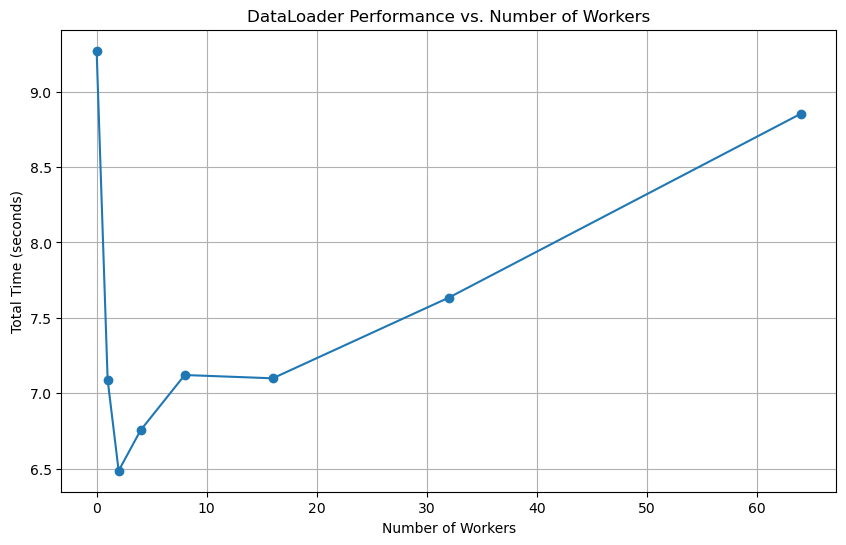


Best configuration: num_workers=2, time=6.49 seconds


In [2]:
class RBDDataset(Dataset):
    def __init__(self, csv_file:str):

        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, target
        return self.full_df['seq_id'][idx], self.full_df['sequence'][idx]

# RUN
torch.manual_seed(0)
data_dir = "../../data/rbd"

results = benchmark_dataloader(
    train_dataset = RBDDataset(os.path.join(data_dir, "spikeprot0528.clean.uniq.noX.RBD.metadata.variants_train.csv")), 
    test_dataset = RBDDataset(os.path.join(data_dir, "spikeprot0528.clean.uniq.noX.RBD.metadata.variants_test.csv")), 
    batch_size = 64, 
    num_workers_list = [0, 1, 2, 4, 8, 16, 32, 64],
    num_epochs = 1
)

plot_results(results)
best_num_workers, best_time = min(results, key=lambda x: x[1])
print(f"\nBest configuration: num_workers={best_num_workers}, time={best_time:.2f} seconds")

Epoch 1/1 (workers=0): 100%|██████████| 1607/1607 [00:03<00:00]


num_workers: 0, time: 3.26 seconds


Epoch 1/1 (workers=1): 100%|██████████| 1607/1607 [00:03<00:00]


num_workers: 1, time: 3.56 seconds


Epoch 1/1 (workers=2): 100%|██████████| 1607/1607 [00:02<00:00]


...

num_workers: 16, time: 3.57 seconds


Epoch 1/1 (workers=32): 100%|██████████| 1607/1607 [00:04<00:00]


num_workers: 32, time: 4.32 seconds


Epoch 1/1 (workers=64): 100%|██████████| 1607/1607 [00:06<00:00]

num_workers: 64, time: 6.67 seconds


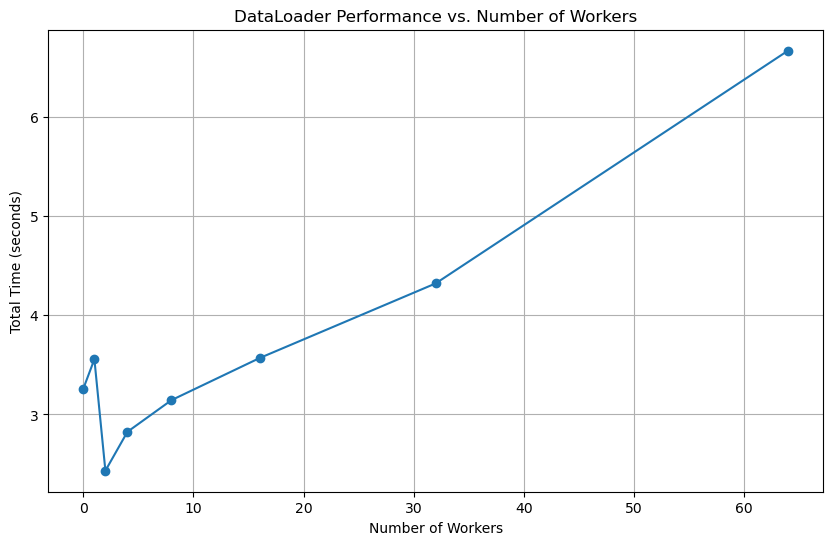


Best configuration: num_workers=2, time=2.43 seconds


In [6]:
class DMSDataset(Dataset):
    """ Binding or Expression DMS Dataset, single target. """
    
    def __init__(self, csv_file:str, result_tag:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding or expression target,
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
            self.target = 'ACE2-binding_affinity' if 'binding' in result_tag else 'RBD_expression'
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df[self.target][idx]

# RUN
torch.manual_seed(0)
data_dir = "../../data/dms"

results = benchmark_dataloader(
    train_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"), "binding"),
    test_dataset = DMSDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"), "binding"),
    batch_size = 64, 
    num_workers_list = [0, 1, 2, 4, 8, 16, 32, 64],
    num_epochs = 1
)

plot_results(results)
best_num_workers, best_time = min(results, key=lambda x: x[1])
print(f"\nBest configuration: num_workers={best_num_workers}, time={best_time:.2f} seconds")

Epoch 1/1 (workers=0): 100%|██████████| 1607/1607 [00:25<00:00]


num_workers: 0, time: 25.17 seconds


Epoch 1/1 (workers=1): 100%|██████████| 1607/1607 [00:33<00:00]


num_workers: 1, time: 33.23 seconds


Epoch 1/1 (workers=2): 100%|██████████| 1607/1607 [00:24<00:00]


...

num_workers: 16, time: 25.72 seconds


Epoch 1/1 (workers=32): 100%|██████████| 1607/1607 [00:34<00:00]


num_workers: 32, time: 34.52 seconds


Epoch 1/1 (workers=64): 100%|██████████| 1607/1607 [00:48<00:00]


num_workers: 64, time: 48.73 seconds


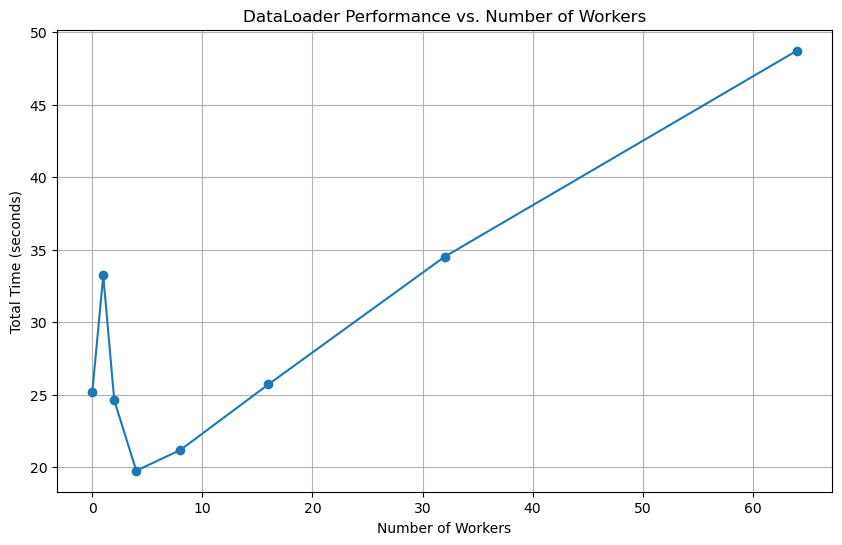


Best configuration: num_workers=4, time=19.77 seconds


In [9]:
class DMSEmbeddedDataset(Dataset):
    """ Binding or Expression DMS Embedded Dataset, single target. """
    
    def __init__(self, tensor_file:str, result_tag:str):
        """
        Load from tensor file into pandas:
        - sequence label ('labels'), 
        - 'embedding',
        - binding target or expression target
        """
        try:
            self.data = torch.load(tensor_file)
            self.target = 'ACE2-binding_affinity' if 'binding' in result_tag else 'RBD_expression'
        except (FileNotFoundError, KeyError, Exception) as e:
            print(f"Error reading the tensor file: {tensor_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.data['label'])

    def __getitem__(self, idx):
        # label, seq, target
        return self.data['label'][idx], self.data['embedding'][idx], self.data[self.target][idx]

# RUN
torch.manual_seed(0)
data_dir = "../../data/dms/pt"

results = benchmark_dataloader(
    train_dataset = DMSEmbeddedDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train_ESM-AA-embedded.pt"), "binding"),
    test_dataset = DMSEmbeddedDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test_ESM-AA-embedded.pt"), "binding"),
    batch_size = 64, 
    num_workers_list = [0, 1, 2, 4, 8, 16, 32, 64],
    num_epochs = 1
)

plot_results(results)
best_num_workers, best_time = min(results, key=lambda x: x[1])
print(f"\nBest configuration: num_workers={best_num_workers}, time={best_time:.2f} seconds")

Epoch 1/1 (workers=0): 100%|██████████| 1607/1607 [00:02<00:00]


num_workers: 0, time: 2.31 seconds


Epoch 1/1 (workers=1): 100%|██████████| 1607/1607 [00:02<00:00]


num_workers: 1, time: 2.99 seconds


Epoch 1/1 (workers=2): 100%|██████████| 1607/1607 [00:02<00:00]


...

num_workers: 16, time: 3.40 seconds


Epoch 1/1 (workers=32): 100%|██████████| 1607/1607 [00:05<00:00]


num_workers: 32, time: 5.02 seconds


Epoch 1/1 (workers=64): 100%|██████████| 1607/1607 [00:06<00:00]

num_workers: 64, time: 6.71 seconds


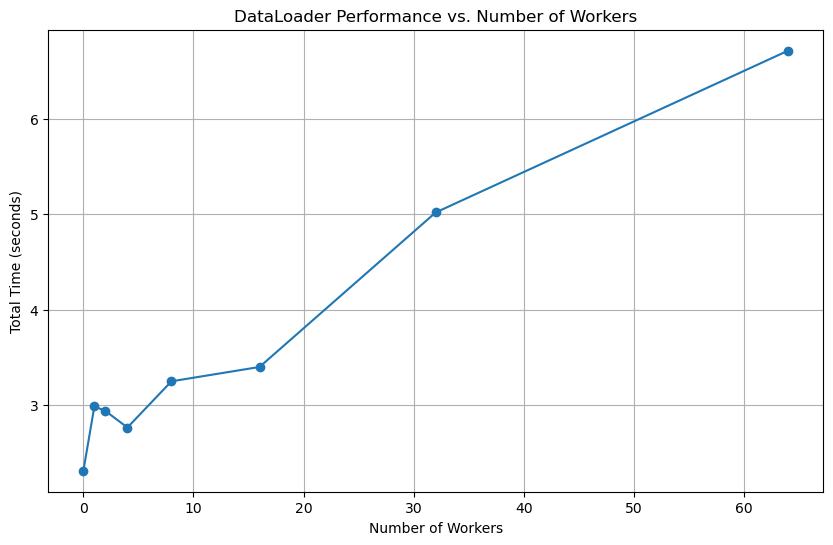


Best configuration: num_workers=0, time=2.31 seconds


In [10]:
# RUN
torch.manual_seed(0)
data_dir = "../../data/dms/pt"

results = benchmark_dataloader(
    train_dataset = DMSEmbeddedDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train_ESM-CLS-embedded.pt"), "binding"),
    test_dataset = DMSEmbeddedDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test_ESM-CLS-embedded.pt"), "binding"),
    batch_size = 64, 
    num_workers_list = [0, 1, 2, 4, 8, 16, 32, 64],
    num_epochs = 1
)

plot_results(results)
best_num_workers, best_time = min(results, key=lambda x: x[1])
print(f"\nBest configuration: num_workers={best_num_workers}, time={best_time:.2f} seconds")

Epoch 1/1 (workers=0): 100%|██████████| 1607/1607 [01:16<00:00]


num_workers: 0, time: 76.27 seconds


Epoch 1/1 (workers=1): 100%|██████████| 1607/1607 [00:31<00:00]


num_workers: 1, time: 31.04 seconds


Epoch 1/1 (workers=2): 100%|██████████| 1607/1607 [00:25<00:00]


...

num_workers: 16, time: 25.48 seconds


Epoch 1/1 (workers=32): 100%|██████████| 1607/1607 [00:33<00:00]


num_workers: 32, time: 33.08 seconds


Epoch 1/1 (workers=64): 100%|██████████| 1607/1607 [00:52<00:00]


num_workers: 64, time: 52.03 seconds


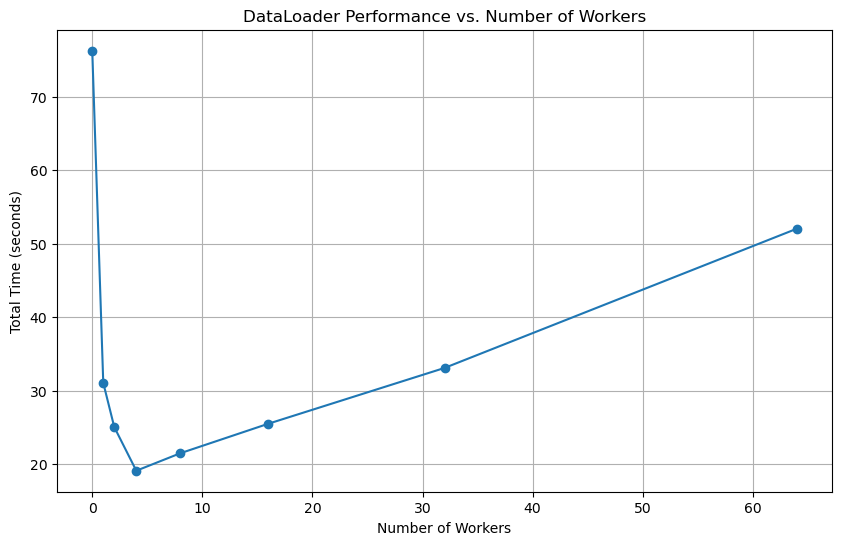


Best configuration: num_workers=4, time=19.08 seconds


In [11]:
# RUN
torch.manual_seed(0)
data_dir = "../../data/dms/pt"

results = benchmark_dataloader(
    train_dataset = DMSEmbeddedDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_train_NLP-embedded.pt"), "binding"),
    test_dataset = DMSEmbeddedDataset(os.path.join(data_dir, "mutation_combined_DMS_OLD_test_NLP-embedded.pt"), "binding"),
    batch_size = 64, 
    num_workers_list = [0, 1, 2, 4, 8, 16, 32, 64],
    num_epochs = 1
)

plot_results(results)
best_num_workers, best_time = min(results, key=lambda x: x[1])
print(f"\nBest configuration: num_workers={best_num_workers}, time={best_time:.2f} seconds")

2 or 4 workers looks like. We'll go with 4.